## Homework 6
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [4]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np

%matplotlib inline

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-03-24 01:00:40,856: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-24 01:00:41,415: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-24 01:00:43,913: Using instance: open-instance, plan: open


## Problem 1

In [5]:
def marked(threshold, states, func):
    marked = []
    for s in states:
        bits = list(map(int, s))
        if func(*bits) < threshold:
            marked.append(s)
    return marked

def oracle(qc, marked_states, states):
    diag = []
    for s in states:
        diag.append(-1 if s in marked_states else 1)
    qc.append(Operator(np.diag(diag)), qc.qubits)

def diffuser(qc, n):
    for qubit in qc.qubits:
        qc.h(qubit)
        qc.x(qubit)
    
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    for qubit in qc.qubits:
        qc.x(qubit)
        qc.h(qubit)

# num_qbits, threshold, iterations, minimizing function
def grover(n, threshold, iterations, func):
    qc = QuantumCircuit(n)
    states = [format(i, f'0{n}b') for i in range(2**n)]

    # initialize
    for qubit in qc.qubits:
        qc.h(qubit)

    for _ in range(iterations):
        oracle(qc, marked(threshold, states, func), states)
        diffuser(qc, n)

    qc.measure_all()
    return qc

## (a)

Counts(ideal): {'110': 807, '011': 35, '000': 36, '111': 32, '101': 27, '100': 32, '010': 25, '001': 30}


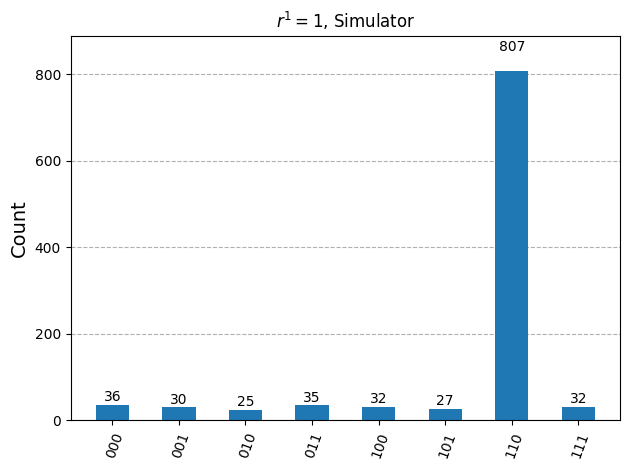

In [6]:
def g(x0, x1, x2):
    return 3*x0*x1 - 2*x1*x2 - x0*x2 + 1

y1 = g(1,1,0)

qc = grover(3, y1, 1, g)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="$r^1 = 1$, Simulator");

## (b)

Counts(ideal): {'110': 976, '011': 5, '001': 4, '000': 9, '101': 6, '010': 7, '111': 10, '100': 7}


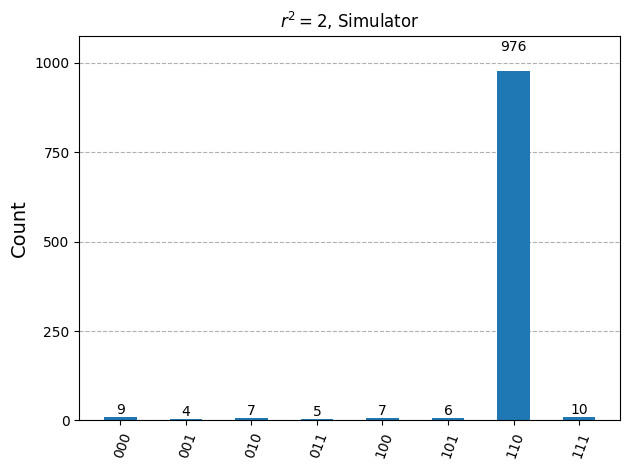

In [7]:
# using x* = (1,1,0)
y2 = g(1,1,0)

qc = grover(3, y2, 2, g)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="$r^2 = 2$, Simulator");

No, $x^{**} = 110$ is not the minimizer of g. The minimizer of g is $011$. Since 7/8 states become marked with 110 as the input x (7/8 thresholds < 4), the GAS algorithm fails to find the minimzer.

## Problem 2.

In [8]:
# graph with vertices V and edges E (square)
V = [0,1,2,3]
E = [(0,1), (1,2), (2,3), (3,0)]

def cut_size(E, x):
    cut = 0
    for i, j in E:
        if x[i] != x[j]:
            cut += 1
    return cut

# (a)

In [9]:
states = [format(i, '04b') for i in range(16)]

best_val = -1 
best_s = None

for s in states:
    val = cut_size(E, s)
    if val > best_val:
        best_val = val
        best_s = s

print(f"Best cut size: {best_val}, Best state = {best_s}")


Best cut size: 4, Best state = 0101


# (b)

We want to minimize:
$$\begin{align*}
\langle x| H |x \rangle &= \langle x| Z_{01} + Z_{12} + Z_{23} + Z_{30}|x \rangle\\
&= z_0z_1 + z_1z_2 + z_2z_3 + z_3z_0
\end{align*}$$

using $z_i = 1-2x_i$:

$$\begin{align*}
&= (1-2x_0)(1-2x_1) + (1-2x_1)(1-2x_2) + (1-2x_2)(1-2x_3) + (1-2x_3)(1-2x_0)\\
&= 1-2x_0-2x_1 + 4x_0x_1 + 1-2x_1-2x_2 + 4x_1x_2 + 1-2x_2-2x_3 + 4x_2x_3 + 1-2x_3-2x_0 + 4x_3x_0\\
&= 4(1-x_0-x_1-x_2-x_3+x_0x_1+x_1x_2+x_2x_3+x_3x_0)
\end{align*}$$

So we want to find x that minimizes: $-x_0-x_1-x_2-x_3+x_0x_1+x_1x_2+x_2x_3+x_3x_0$


Counts(ideal): {'0101': 481, '1010': 484, '1110': 6, '0111': 5, '0100': 10, '1101': 5, '0010': 5, '0110': 5, '1000': 4, '0011': 2, '1001': 5, '1111': 3, '1100': 5, '1011': 1, '0000': 2, '0001': 1}
Cut size: 4, State: 1010


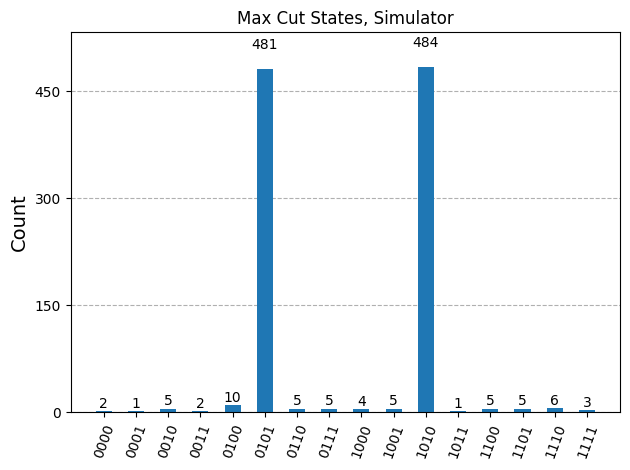

In [10]:
def f(x_0,x_1,x_2,x_3):
    return -x_0 - x_1 - x_2 - x_3 + x_0*x_1 + x_1*x_2 + x_2*x_3 + x_3*x_0

y1 = f(0,1,1,0)
ideal_iter = int(np.round(np.pi/4 * np.sqrt(16/4)))
qc = grover(4, y1, ideal_iter, f)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="Max Cut States, Simulator");

best_state = max(counts, key=counts.get)
print(f"Cut size: {cut_size(E, best_state)}, State: {best_state}")

Counts(ideal): {'0001': 4, '0111': 9, '1010': 35, '0101': 39, '1111': 1, '1100': 3, '1001': 7, '1110': 3, '1101': 4, '0000': 1, '0011': 4, '0110': 3, '0010': 2, '1000': 7, '0100': 4, '1011': 2}
Cut size: 4, State: 0101


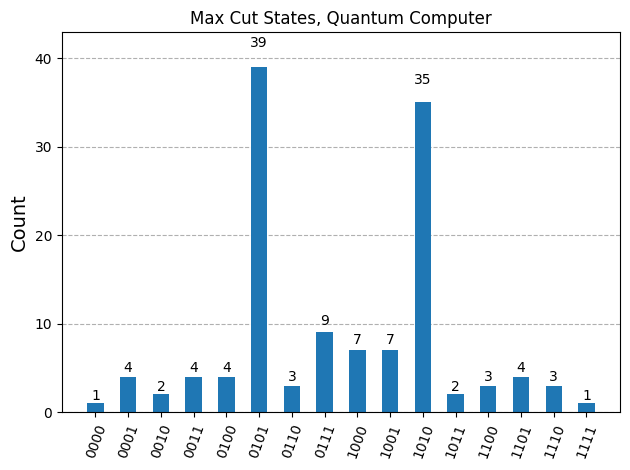

In [11]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="Max Cut States, Quantum Computer");

best_state = max(counts, key=counts.get)
print(f"Cut size: {cut_size(E, best_state)}, State: {best_state}")

# Problem 3. (Knapsack)

# (a)

In [12]:
states = [format(i, '04b') for i in range(16)]

items = [
    {"value": 8, "weight": 4},
    {"value": 11, "weight": 5},
    {"value": 6, "weight": 3},
    {"value": 4, "weight": 2}
]
cap = 10

def value(s):
    val = 0
    weight = 0
    for i in range(len(s)):
        if int(s[i]):
            val += items[i]["value"]
            weight += items[i]["weight"]
    if weight > cap:
        return -1
    return val

best_val = -1
best_s = None

for s in states:
    val = value(s)
    if val > best_val:
        best_val = val
        best_s = s

print(f"Best value: {best_val}, Best state = {best_s}")

Best value: 21, Best state = 0111


# (b)
We want to minimize $-(8x_0 + 11x_1 + 6x_2 + 4x_3)$ subject to $4x_0 + 5x_1 + 3x_2 + 2x_3 \leq 10$

Slack variable for constraint: $s = y_0 + 2y_1 + 4y_2 + 8y_3$ where $y_i \in \{0,1\}$

So constraint becomes $4x_0 + 5x_1 + 3x_2 + 2x_3 + y_0 + 2y_1 + 4y_2 + 8y_3 = 10$

With penalty term: minimize $-(8x_0 + 11x_1 + 6x_2 + 4x_3) + B(4x_0 + 5x_1 + 3x_2 + 2x_3 + y_0 + 2y_1 + 4y_2 + 8y_3 - 10)^2$

Choose B large enough: $B=30>8+11+6+4$

Since $max(30*(weight+s-10)^2) \approx 30*(10)^2 = 3000$, we need $n$ value qubits such that $2^n > 3000$.

So we need at least 12 value qubits.

# (c)

In [13]:
def f(x_0,x_1,x_2,x_3):
    value = 8*x_0 + 11*x_1 + 6*x_2 + 4*x_3
    weight = 4*x_0 + 5*x_1 + 3*x_2 + 2*x_3
    if weight > 10:
        return 1000
    return -value

y1 = f(1,0,0,1)
best_state = None
print("Grover on Original Problem, Simulator")
for i in range(8):
    qc = grover(4, y1, 1, f)
    result = sampler.run([qc], shots=1024).result()
    counts = result[0].data.meas.get_counts()

    state = max(counts, key=counts.get)
    val = f(*map(int, state))

    if val < y1:
        best_state = state
        y1 = val

    print(f"Iteration {i}: Best state = {best_state}, Best value: {value(best_state)}")

Grover on Original Problem, Simulator
Iteration 0: Best state = 1011, Best value: 18
Iteration 1: Best state = 1100, Best value: 19
Iteration 2: Best state = 0111, Best value: 21
Iteration 3: Best state = 0111, Best value: 21
Iteration 4: Best state = 0111, Best value: 21
Iteration 5: Best state = 0111, Best value: 21
Iteration 6: Best state = 0111, Best value: 21
Iteration 7: Best state = 0111, Best value: 21


In [17]:
def f(x_0,x_1,x_2,x_3):
    value = 8*x_0 + 11*x_1 + 6*x_2 + 4*x_3
    weight = 4*x_0 + 5*x_1 + 3*x_2 + 2*x_3
    if weight > 10:
        return 1000
    return -value

y1 = f(1,0,0,1)
best_state = None
print("Grover on Original Problem, Quantum Computer")
for i in range(5):
    qc = grover(4, y1, 1, f)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)

    job = ibmsampler.run([isa_circuit], shots=128)

    result = job.result()
    counts = result[0].data.meas.get_counts()

    state = max(counts, key=counts.get)
    val = f(*map(int, state))

    if val < y1:
        best_state = state
        y1 = val

    print(f"Iteration {i}: Best state = {best_state}, Best value: {value(best_state)}")

Grover on Original Problem, Quantum Computer
Iteration 0: Best state = 1011, Best value: 18
Iteration 1: Best state = 0111, Best value: 21
Iteration 2: Best state = 0111, Best value: 21
Iteration 3: Best state = 0111, Best value: 21
Iteration 4: Best state = 0111, Best value: 21


In [ ]:
def f(x_0,x_1,x_2,x_3,y_0,y_1,y_2,y_3):
    value = 8*x_0 + 11*x_1 + 6*x_2 + 4*x_3
    weight = 4*x_0 + 5*x_1 + 3*x_2 + 2*x_3
    s = y_0 + 2*y_1 + 4*y_2 + 8*y_3
    return -value + 30*(weight + s - 10)**2

y1 = f(0,0,0,0,0,1,0,1)
best_state = None
print("Grover on QUBO, Simulator")
for i in range(8):
    qc = grover(8, y1, 1, f)
    result = sampler.run([qc], shots=1024).result()
    counts = result[0].data.meas.get_counts()

    state = max(counts, key=counts.get)
    val = f(*map(int, state))

    if val < y1:
        best_state = state
        y1 = val

    # print exludes slack variables
    print(f"Iteration {i}: Best state = {best_state[:4]}, Best value: {value(best_state[:4])}")

Grover on QUBO, Simulator
Iteration 0: Best state = 1011, Best value: 18
Iteration 1: Best state = 1100, Best value: 19
Iteration 2: Best state = 0111, Best value: 21
Iteration 3: Best state = 0111, Best value: 21
Iteration 4: Best state = 0111, Best value: 21
Iteration 5: Best state = 0111, Best value: 21
Iteration 6: Best state = 0111, Best value: 21
Iteration 7: Best state = 0111, Best value: 21


In [20]:
def f(x_0,x_1,x_2,x_3,y_0,y_1,y_2,y_3):
    value = 8*x_0 + 11*x_1 + 6*x_2 + 4*x_3
    weight = 4*x_0 + 5*x_1 + 3*x_2 + 2*x_3
    s = y_0 + 2*y_1 + 4*y_2 + 8*y_3
    return -value + 30*(weight + s - 10)**2

y1 = f(0,0,0,0,1,1,1,1)
best_state = None
print("Grover on QUBO, Quantum Computer")
for i in range(3):
    qc = grover(8, y1, 1, f)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)

    job = ibmsampler.run([isa_circuit], shots=128)

    result = job.result()
    counts = result[0].data.meas.get_counts()

    state = max(counts, key=counts.get)
    val = f(*map(int, state))

    if val < y1:
        best_state = state
        y1 = val

    # print exludes slack variables
    if best_state is not None:
        print(f"Iteration {i}: Best state = {best_state[:4]}, Best value: {value(best_state[:4])}")
    else:
        print(f"Iteration {i}: No valid state found")
    

Grover on QUBO, Quantum Computer
Iteration 0: Best state = 0001, Best value: 4
Iteration 1: Best state = 0011, Best value: 10
Iteration 2: Best state = 0011, Best value: 10


Most results converged on a maximum value of 21 on state 0111. Grover on Qubo on IBM quantum computers found a best value of 10 on state 0011. I suspect that running more than 3 iterations would increase accuracy, however even just 3 iterations takes a significant time to compute on 8-qubit circuits.